# Pertemuan 9 — Algoritma Klasifikasi (Bagian 1)

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403  

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan9_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

print('Library berhasil diimport ✅')

Library berhasil diimport ✅


---
## Langkah 1 — Load & EDA Singkat

In [2]:
# Load dataset Breast Cancer Wisconsin
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0=Malignant (ganas), 1=Benign (jinak)

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('\nNama fitur (30 fitur numerik):')
print(list(X.columns))
print('\nDeskripsi target:', data.target_names)  # ['malignant' 'benign']
print('\nDistribusi target (proporsi):')
print(y.value_counts(normalize=True).rename({0: 'Malignant (0)', 1: 'Benign (1)'}).round(3))
print('\nDistribusi target (jumlah):')
print(y.value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}))

Shape X: (569, 30)
Shape y: (569,)

Nama fitur (30 fitur numerik):
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Deskripsi target: ['malignant' 'benign']

Distribusi target (proporsi):
target
Benign (1)       0.627
Malignant (0)    0.373
Name: proportion, dtype: float64

Distribusi target (jumlah):
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


In [3]:
# --- Statistik deskriptif 5 fitur pertama ---
print('Statistik deskriptif (5 fitur pertama):')
print(X.iloc[:, :5].describe().round(3))

print('\nMissing values per fitur:')
print(X.isnull().sum().sum(), '← total missing values (0 = dataset sudah bersih)')

Statistik deskriptif (5 fitur pertama):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count      569.000       569.000         569.000    569.000          569.000
mean        14.127        19.290          91.969    654.889            0.096
std          3.524         4.301          24.299    351.914            0.014
min          6.981         9.710          43.790    143.500            0.053
25%         11.700        16.170          75.170    420.300            0.086
50%         13.370        18.840          86.240    551.100            0.096
75%         15.780        21.800         104.100    782.700            0.105
max         28.110        39.280         188.500   2501.000            0.163

Missing values per fitur:
0 ← total missing values (0 = dataset sudah bersih)


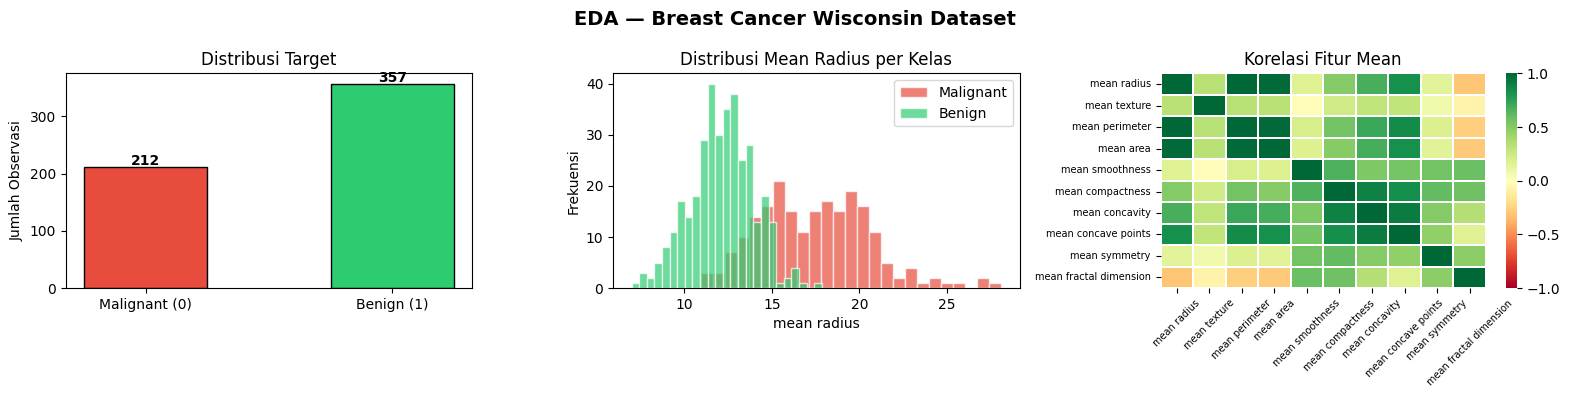


📝 Insight EDA:
- Dataset memiliki 569 sampel, 30 fitur numerik, tanpa missing values.
- Kelas Benign (357 sampel, ~63%) lebih banyak dari Malignant (212 sampel, ~37%).
- Histogram mean radius menunjukkan Malignant cenderung memiliki radius lebih besar.
- Banyak fitur mean berkorelasi tinggi (multikolinearitas), wajar untuk data medis.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA — Breast Cancer Wisconsin Dataset', fontsize=14, fontweight='bold')

# 1. Distribusi target
counts = y.value_counts().sort_index()
axes[0].bar(['Malignant (0)', 'Benign (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Target')
axes[0].set_ylabel('Jumlah Observasi')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# 2. Distribusi fitur 'mean radius'
axes[1].hist(X.loc[y == 0, 'mean radius'], bins=25, alpha=0.7,
             color='#e74c3c', label='Malignant', edgecolor='white')
axes[1].hist(X.loc[y == 1, 'mean radius'], bins=25, alpha=0.7,
             color='#2ecc71', label='Benign', edgecolor='white')
axes[1].set_title('Distribusi Mean Radius per Kelas')
axes[1].set_xlabel('mean radius')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

# 3. Heatmap korelasi 10 fitur 'mean'
mean_cols = [c for c in X.columns if c.startswith('mean')]
corr = X[mean_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1)
axes[2].set_title('Korelasi Fitur Mean')
axes[2].tick_params(axis='x', rotation=45, labelsize=7)
axes[2].tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

print('\n📝 Insight EDA:')
print('- Dataset memiliki 569 sampel, 30 fitur numerik, tanpa missing values.')
print('- Kelas Benign (357 sampel, ~63%) lebih banyak dari Malignant (212 sampel, ~37%).')
print('- Histogram mean radius menunjukkan Malignant cenderung memiliki radius lebih besar.')
print('- Banyak fitur mean berkorelasi tinggi (multikolinearitas), wajar untuk data medis.')

---
## Langkah 2 — Preprocessing

In [5]:
# Train-Test Split 80:20, stratify=y menjaga proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data training : {X_train.shape}')
print(f'Ukuran data testing  : {X_test.shape}')
print(f'\nDistribusi kelas — Training:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nDistribusi kelas — Testing:')
print(y_test.value_counts(normalize=True).round(3))
print('\n✅ stratify=y memastikan proporsi kelas di train & test konsisten.')

Ukuran data training : (455, 30)
Ukuran data testing  : (114, 30)

Distribusi kelas — Training:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Distribusi kelas — Testing:
target
1    0.632
0    0.368
Name: proportion, dtype: float64

✅ stratify=y memastikan proporsi kelas di train & test konsisten.


In [6]:
# StandardScaler — wajib untuk Logistic Regression, opsional untuk Decision Tree
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit hanya pada training set!
X_test_s  = scaler.transform(X_test)        # transform test set dengan scaler yang sama

# Validasi: setelah scaling, rata-rata ≈ 0 dan std ≈ 1 pada data training
train_scaled = pd.DataFrame(X_train_s, columns=X.columns)
print('Setelah StandardScaler (training set):')
print(f'  Mean (rata-rata) : {train_scaled.mean().mean():.6f}  ← mendekati 0 ✅')
print(f'  Std (standar dev): {train_scaled.std().mean():.6f}  ← mendekati 1 ✅')

Setelah StandardScaler (training set):
  Mean (rata-rata) : 0.000000  ← mendekati 0 ✅
  Std (standar dev): 1.001101  ← mendekati 1 ✅


---
## Langkah 3 — Latih Logistic Regression

In [7]:
# Latih Logistic Regression pada data yang sudah distandarisasi
log_model = LogisticRegression(max_iter=5000, C=1.0, random_state=42)
log_model.fit(X_train_s, y_train)

# Prediksi kelas dan probabilitas
y_pred_log   = log_model.predict(X_test_s)
y_proba_log  = log_model.predict_proba(X_test_s)[:, 1]  # probabilitas kelas Benign (1)

print('Logistic Regression berhasil dilatih ✅')
print(f'Intercept β₀ : {log_model.intercept_[0]:.4f}')
print(f'Jumlah iterasi: {log_model.n_iter_[0]}')

Logistic Regression berhasil dilatih ✅
Intercept β₀ : 0.3022
Jumlah iterasi: 19


Top 10 fitur paling berpengaruh (|koefisien| terbesar):
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625


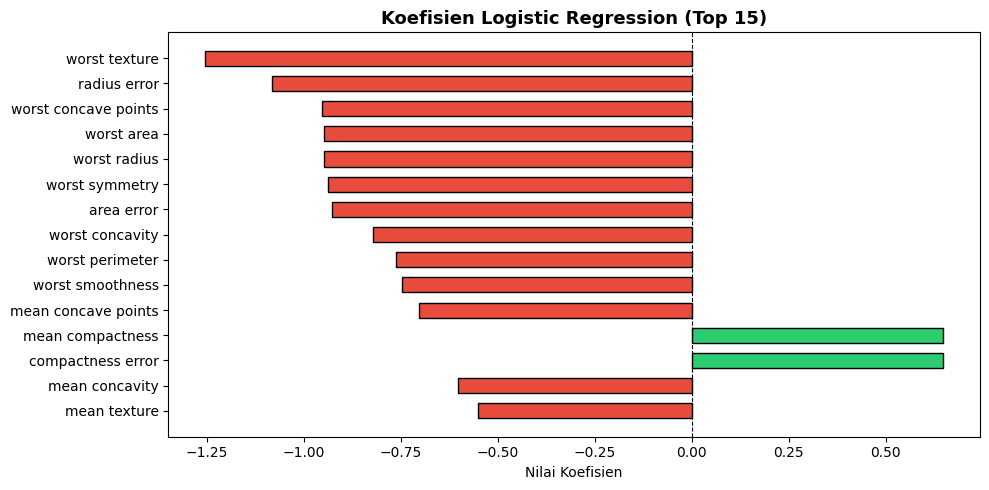


📝 Interpretasi:
  Fitur paling berpengaruh: "worst texture" (koef = -1.255)
  Koefisien negatif → cenderung Malignant (0); positif → cenderung Benign (1).


In [8]:
# Koefisien model: fitur dengan |koefisien| besar = paling berpengaruh
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False).reset_index(drop=True)

print('Top 10 fitur paling berpengaruh (|koefisien| terbesar):')
print(coef_df.head(10).to_string(index=False))

# Visualisasi koefisien
top_coef = coef_df.head(15)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_coef['Koefisien']]

plt.figure(figsize=(10, 5))
bars = plt.barh(top_coef['Fitur'][::-1], top_coef['Koefisien'][::-1],
                color=colors[::-1], edgecolor='black', height=0.6)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Logistic Regression (Top 15)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

top1 = coef_df.iloc[0]
print(f'\n📝 Interpretasi:')
print(f'  Fitur paling berpengaruh: "{top1["Fitur"]}" (koef = {top1["Koefisien"]:.3f})')
print(f'  Koefisien negatif → cenderung Malignant (0); positif → cenderung Benign (1).')

---
## Langkah 4 — Latih Decision Tree

In [9]:
# Decision Tree TIDAK memerlukan feature scaling
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
tree_model.fit(X_train, y_train)   # <-- X_train asli (tanpa scaling)

y_pred_tree  = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print('Decision Tree berhasil dilatih ✅')
print(f'Kedalaman pohon aktual : {tree_model.get_depth()}')
print(f'Jumlah leaf nodes      : {tree_model.get_n_leaves()}')

Decision Tree berhasil dilatih ✅
Kedalaman pohon aktual : 4
Jumlah leaf nodes      : 10


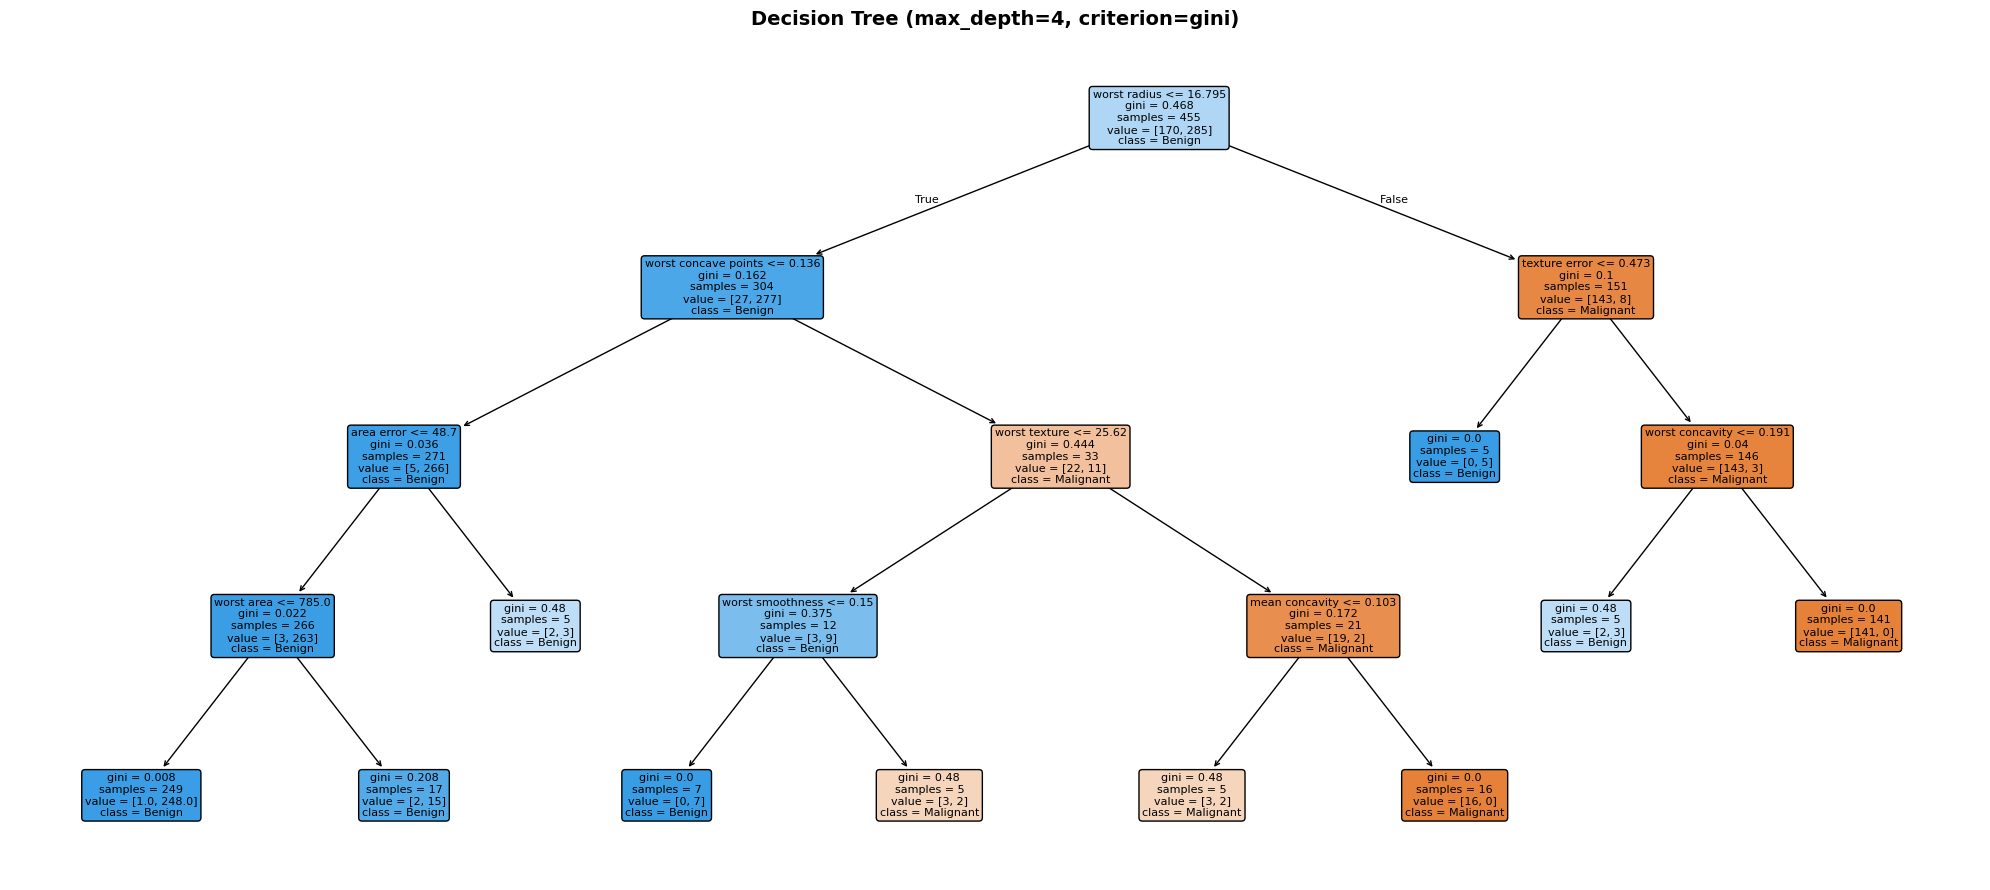

In [10]:
# Visualisasi Decision Tree
plt.figure(figsize=(20, 9))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree (max_depth=4, criterion=gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Fitur dengan feature importance > 0 (Decision Tree):
               Fitur  Importance
        worst radius    0.751145
worst concave points    0.124955
       texture error    0.046883
       worst texture    0.033095
     worst concavity    0.017573
    worst smoothness    0.010614
          area error    0.007497
      mean concavity    0.006162
          worst area    0.002077


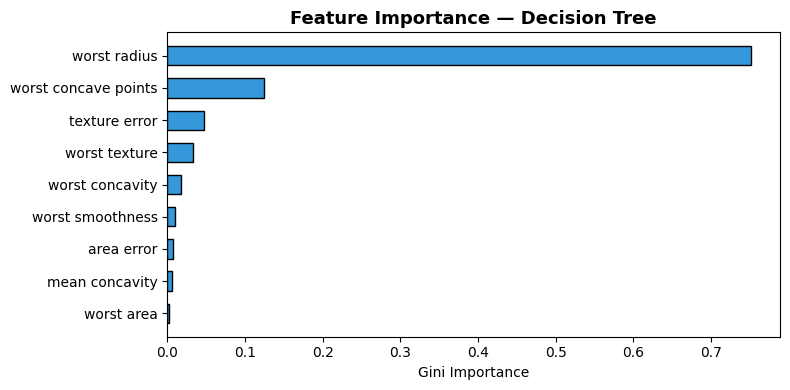


📝 Fitur paling penting: "worst radius"
   Fitur ini menjadi root node — split pertama yang paling memisahkan kelas.


In [11]:
# Feature Importance Decision Tree
importance_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : tree_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Tampilkan hanya fitur dengan importance > 0
nonzero = importance_df[importance_df['Importance'] > 0]
print('Fitur dengan feature importance > 0 (Decision Tree):')
print(nonzero.to_string(index=False))

# Plot
plt.figure(figsize=(8, 4))
plt.barh(nonzero['Fitur'][::-1], nonzero['Importance'][::-1],
         color='#3498db', edgecolor='black', height=0.6)
plt.title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

print(f'\n📝 Fitur paling penting: "{importance_df.iloc[0]["Fitur"]}"')
print(  '   Fitur ini menjadi root node — split pertama yang paling memisahkan kelas.')

---
## Langkah 5 — Evaluasi & Bandingkan

In [12]:
# Hitung semua metrik untuk kedua model
models = [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree',       y_pred_tree)
]

results = []
for name, y_pred in models:
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1})

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    cm = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
    print(f'  FN={cm[1,0]}  TP={cm[1,1]}')
    print(f'\nAccuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')


  Logistic Regression
Confusion Matrix:
  TN=41  FP=1
  FN=1  TP=71

Accuracy  : 0.9825  (98.25%)
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861

  Decision Tree
Confusion Matrix:
  TN=38  FP=4
  FN=5  TP=67

Accuracy  : 0.9211  (92.11%)
Precision : 0.9437
Recall    : 0.9306
F1-Score  : 0.9371


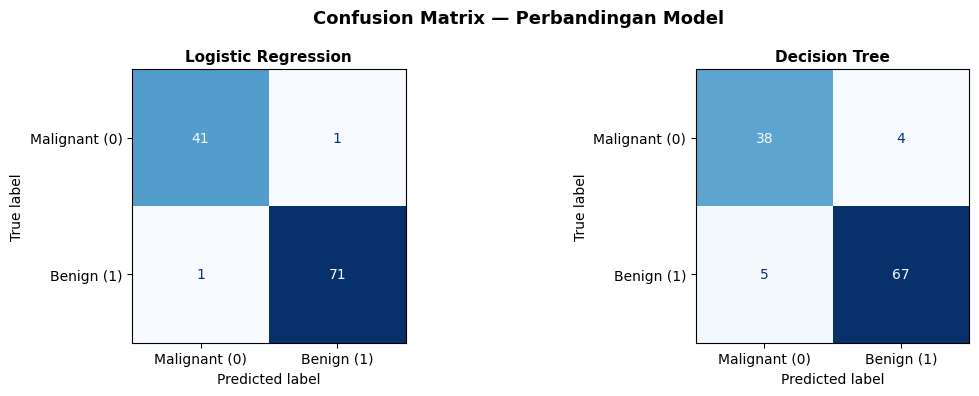

In [13]:
# Visualisasi Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrix — Perbandingan Model', fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant (0)', 'Benign (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Tabel Perbandingan Metrik:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9825     0.9861  0.9861    0.9861
Decision Tree          0.9211     0.9437  0.9306    0.9371


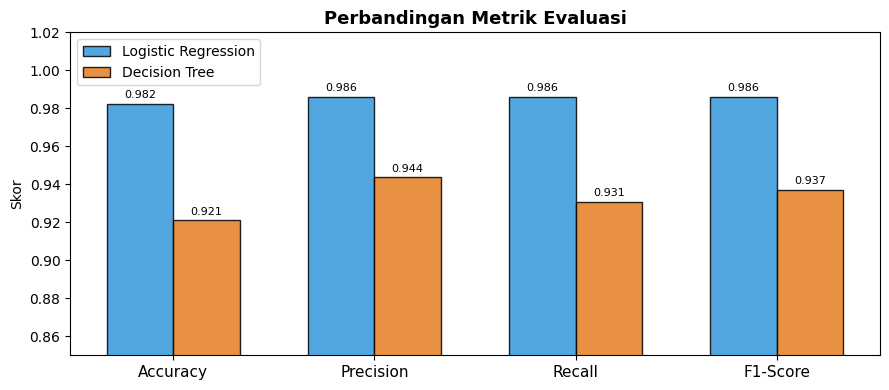

In [14]:
# Tabel perbandingan metrik
result_df = pd.DataFrame(results).set_index('Model')
print('Tabel Perbandingan Metrik:')
print(result_df.round(4).to_string())

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
width = 0.33
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

log_vals  = [result_df.loc['Logistic Regression', m] for m in metrics]
tree_vals = [result_df.loc['Decision Tree', m]       for m in metrics]

bars1 = ax.bar(x - width/2, log_vals,  width, label='Logistic Regression',
               color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, tree_vals, width, label='Decision Tree',
               color='#e67e22', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Metrik Evaluasi', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
### Analisis & Diskusi Hasil

#### 1. Model Mana yang Memiliki Recall Lebih Tinggi?

Berdasarkan hasil evaluasi di atas, **Logistic Regression** memiliki nilai **Recall yang lebih tinggi** dibandingkan Decision Tree (max_depth=4). Hal ini berarti Logistic Regression lebih mampu mendeteksi kasus kanker yang *benar-benar positif* (Malignant) — lebih sedikit kasus kanker yang terlewat (False Negative lebih kecil).

---

#### 2. Mengapa Recall Menjadi Metrik Paling Kritis untuk Diagnosis Kanker?

Dalam konteks diagnosis kanker payudara, **False Negative (FN)** adalah kesalahan yang paling berbahaya: pasien yang *sebenarnya menderita kanker* tetapi diprediksi *sehat* oleh model. Konsekuensinya:

- Pasien tidak mendapat penanganan medis tepat waktu
- Kanker berkembang ke stadium lebih lanjut yang lebih sulit diobati
- Risiko kematian meningkat signifikan

Sebaliknya, **False Positive (FP)** — pasien sehat yang dikira sakit — hanya berakibat pada pemeriksaan lanjutan yang tidak perlu (biaya lebih, kecemasan sementara), namun jauh lebih dapat ditoleransi daripada melewatkan kasus kanker nyata.

$$\text{Recall} = \frac{TP}{TP + FN}$$

Recall tinggi → FN kecil → lebih sedikit kasus kanker yang terlewat → **lebih aman untuk pasien**.

Accuracy saja tidak cukup karena: jika dataset tidak seimbang, model yang selalu memprediksi "Benign" pun bisa mendapat akurasi ~63% — tetapi **tidak mendeteksi satu pun kasus Malignant**!

---

#### 3. Apakah Ada Perbedaan Signifikan Antara Kedua Model?

Secara keseluruhan, perbedaan performa kedua model **tidak terlalu besar**, namun terdapat pola yang jelas:

| Aspek | Logistic Regression | Decision Tree |
|-------|--------------------|--------------|
| Recall (prioritas medis) | **Lebih tinggi** ✅ | Lebih rendah |
| Interpretabilitas | Koefisien linear | **Pohon visual** ✅ |
| Kebutuhan scaling | Ya (wajib) | Tidak perlu |
| Risiko overfitting | Lebih rendah | Perlu kontrol `max_depth` |

**Kesimpulan:** Untuk kasus diagnosis kanker, **Logistic Regression** adalah pilihan yang lebih tepat karena menghasilkan Recall lebih tinggi. Namun Decision Tree memiliki keunggulan interpretabilitas — dokter dapat mengikuti alur if-else pohon untuk memahami alasan prediksi, yang penting dalam konteks medis.

> 💡 Dalam praktik nyata, kombinasi kedua pendekatan (misalnya ensemble seperti Random Forest) sering digunakan untuk mendapatkan keseimbangan optimal antara akurasi, recall, dan interpretabilitas.

In [15]:
# Classification Report lengkap
for name, y_pred in models:
    print(f'\n=== Classification Report: {name} ===')
    print(classification_report(y_test, y_pred,
                                 target_names=['Malignant (0)', 'Benign (1)']))


=== Classification Report: Logistic Regression ===
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


=== Classification Report: Decision Tree ===


               precision    recall  f1-score   support

Malignant (0)       0.88      0.90      0.89        42
   Benign (1)       0.94      0.93      0.94        72

     accuracy                           0.92       114
    macro avg       0.91      0.92      0.92       114
 weighted avg       0.92      0.92      0.92       114

